In [18]:
# Write your imports here
from skimage.io import imread
import os
import shutil
import hashlib
import imagehash
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats 
from collections import Counter
from PIL import Image

# Working with Images Lab
## Information retrieval, preprocessing, and feature extraction

In this lab, you'll work with images of felines (cats), which have been classified according to their taxonomy. Each subfolder contains images of a particular species. The dataset is located [here](https://www.kaggle.com/datasets/datahmifitb/felis-taxonomy-image-classification) but it's also provided to you in the `data/` folder.

### Problem 1. Some exploration (1 point)
How many types of cats are there? How many images do we have of each? What is a typical image size? Are there any outliers in size?

In [2]:
# The path to the images
data_path = "data/"

# Count types of data
types = [folder for folder in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, folder))]
print("Cat Types Counts: ", len(types))
print("Cat Types Names: ", types)

print("\n" + "-"*50 + "\nCOUNT OF IMAGES IN EACH FOLDER:")
# Count images in each folder
all_widths = []
all_heights = []
for t in types:
    folder_path = os.path.join(data_path, t)
    images = [f for f in os.listdir(folder_path) if f.endswith(".jpg") or f.endswith(".png")]
    
    # Image sizes 
    widths = []
    heights = []
    
    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        img = imread(img_path)
        h, w = img.shape[:2] 
        heights.append(h)
        widths.append(w)
        all_heights.append(h)
        all_widths.append(w)

    # Typical image size - I find the mode to see which size is most frequent. 
    # I chose the mode because it is robust to outliers and is most accurate.
    typical_height = stats.mode(heights, keepdims=True).mode[0]
    typical_width = stats.mode(widths, keepdims=True).mode[0]

    print(f"{t}: {len(images)} images, Typical size: {typical_width}x{typical_height}")

print()

# Typical size for the whole dataset
typical_height_whole = stats.mode(all_heights, keepdims=True).mode[0]
typical_width_whole = stats.mode(all_widths, keepdims=True).mode[0]

print(f"TYPICAL SIZE FOR THE WHOLE DATASET: {typical_width}x{typical_height}")

Cat Types Counts:  7
Cat Types Names:  ['african-wildcat', 'blackfoot-cat', 'chinese-mountain-cat', 'domestic-cat', 'european-wildcat', 'jungle-cat', 'sand-cat']

--------------------------------------------------
COUNT OF IMAGES IN EACH FOLDER:
african-wildcat: 91 images, Typical size: 275x183
blackfoot-cat: 79 images, Typical size: 183x183
chinese-mountain-cat: 42 images, Typical size: 800x183
domestic-cat: 64 images, Typical size: 275x183
european-wildcat: 85 images, Typical size: 1300x183
jungle-cat: 86 images, Typical size: 275x183
sand-cat: 72 images, Typical size: 275x183

TYPICAL SIZE FOR THE WHOLE DATASET: 275x183


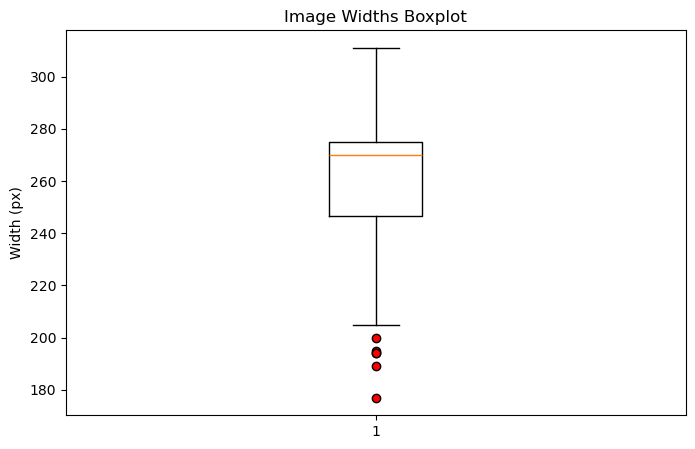

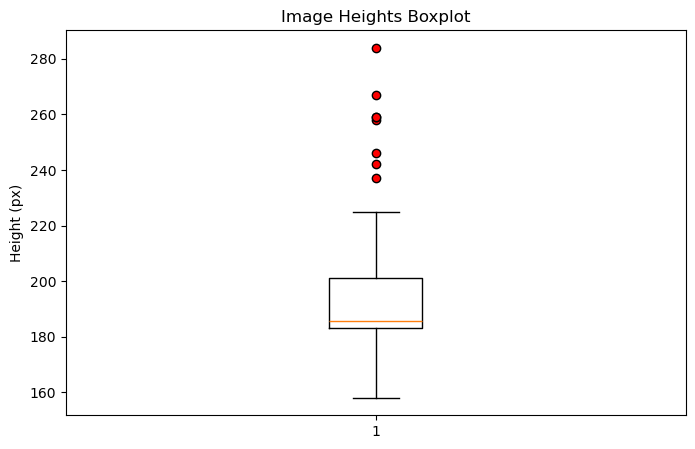

In [3]:
# Boxplot for images widths
plt.figure(figsize=(8,5))
plt.boxplot(widths, flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title("Image Widths Boxplot")
plt.ylabel("Width (px)")
plt.show()

# Boxplot for images heights
plt.figure(figsize=(8,5))
plt.boxplot(heights, flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title("Image Heights Boxplot")
plt.ylabel("Height (px)")
plt.show()

There is a moderate count of outliers. Let's see them:

In [4]:
def find_outliers(values):
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = [v for v in values if v < lower_bound or v > upper_bound]
    return outliers, lower_bound, upper_bound

# Outliers for widths
width_outliers, w_low, w_high = find_outliers(all_widths)
print(f"Width outliers ({len(width_outliers)}):", width_outliers)
print(f"WIDTH NORMAL RANGE: [{w_low}, {w_high}]")

print()

# Outliers for heights
height_outliers, h_low, h_high = find_outliers(all_heights)
print(f"Height outliers ({len(height_outliers)}):", height_outliers)
print(f"HEIGHT NORMAL RANGE: [{h_low}, {h_high}]")

Width outliers (156): [183, 195, 191, 195, 195, 189, 191, 183, 183, 183, 150, 177, 183, 183, 192, 189, 182, 184, 183, 194, 192, 183, 177, 183, 183, 183, 182, 183, 184, 183, 194, 183, 183, 183, 1024, 1280, 1500, 636, 640, 4000, 800, 1000, 636, 525, 4000, 2048, 1280, 960, 635, 187, 720, 1644, 800, 810, 184, 650, 800, 571, 1280, 1280, 850, 1500, 600, 800, 800, 4045, 548, 177, 178, 183, 195, 183, 194, 196, 1832, 2000, 1200, 745, 500, 1300, 1600, 390, 793, 800, 500, 960, 600, 800, 524, 720, 2000, 1440, 1300, 2000, 800, 600, 1600, 1200, 1080, 1050, 1024, 600, 1470, 626, 1024, 1300, 195, 390, 183, 1440, 548, 2048, 640, 1023, 384, 1000, 1280, 626, 1000, 745, 1200, 1300, 600, 390, 600, 1300, 2000, 1300, 793, 548, 1023, 960, 800, 524, 1300, 1440, 1618, 720, 1080, 192, 181, 189, 194, 150, 183, 193, 183, 340, 181, 183, 183, 177, 189, 195, 194, 194]
WIDTH NORMAL RANGE: [197.25, 339.25]

Height outliers (84): [684, 858, 1038, 477, 427, 3000, 500, 675, 477, 3000, 1365, 858, 540, 455, 440, 2598, 471, 

Let's look at the typical image size: 275x183 [width : height]. It is in the normal range as it should be so I think my calculations are right.

### Problem 2. Duplicat(e)s (1 point)
Find a way to filter out (remove) identical images. I would recommnend using file hashes, but there are many approaches. Keep in mind that during file saving, recompression, etc., a lot of artifacts can change the file content (bytes), but not visually.

In [5]:
""" SIMPLE HASHING 
    Only detects exact duplicates.
    Will not catch resized, re-saved, or slightly modified images.
    Cannot detect visual similarity; 
    Very fast performance
"""

def file_hash(path):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

hashes = {}
duplicates = []

for root, _, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith((".jpg", ".png")):
            full_path = os.path.join(root, f)
            h = file_hash(full_path)
            if h in hashes:
                duplicates.append(full_path)   # duplicate found
            else:
                hashes[h] = full_path

print("Exact duplicates found:", len(duplicates))


Exact duplicates found: 30


In [6]:
""" GRAYSCALE CONVERTION METHOD 
    Sensitive to threshold; ignores color
    Slow (O(n²)) performance
"""

def preprocess_image(path, size=(32, 32)):
    """Load image, convert to grayscale, resize, return as normalized vector."""
    img = Image.open(path).convert("L")  # convert to grayscale
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0  # normalize [0,1]
    return arr.flatten()

def mse(img1, img2):
    """Mean Squared Error between two image vectors."""
    return np.mean((img1 - img2) ** 2)

def find_duplicates_numpy(data_path, threshold=0.001):
    """
    Find visually similar images using NumPy.
    threshold: lower = stricter (0 → only exact same)
    """
    images = []
    paths = []

    for root, _, files in os.walk(data_path):
        for f in files:
            if f.lower().endswith((".jpg", ".png", ".jpeg")):
                full_path = os.path.join(root, f)
                try:
                    vec = preprocess_image(full_path)
                    images.append(vec)
                    paths.append(full_path)
                except Exception as e:
                    print("Error reading", full_path, ":", e)

    duplicates = []
    checked = set()

    for i in range(len(images)):
        for j in range(i+1, len(images)):
            if (i, j) in checked:
                continue
            dist = mse(images[i], images[j])
            if dist < threshold:  # almost identical images
                duplicates.append((paths[i], paths[j], dist))
            checked.add((i, j))

    return duplicates

data_path = "data/"
dups = find_duplicates_numpy(data_path)

print("Визуални дубликати:", len(dups))
for d1, d2, dist in dups:
    print(f"{d1} <--> {d2}, mse={dist:.6f}")


Визуални дубликати: 95
data/african-wildcat\af (11).jpg <--> data/african-wildcat\af (37).jpg, mse=0.000082
data/african-wildcat\af (11).jpg <--> data/african-wildcat\.ipynb_checkpoints\af (11)-checkpoint.jpg, mse=0.000000
data/african-wildcat\af (11).jpg <--> data/african-wildcat\.ipynb_checkpoints\af (37)-checkpoint.jpg, mse=0.000082
data/african-wildcat\af (13).jpg <--> data/african-wildcat\af (47).jpg, mse=0.000005
data/african-wildcat\af (13).jpg <--> data/african-wildcat\.ipynb_checkpoints\af (13)-checkpoint.jpg, mse=0.000000
data/african-wildcat\af (13).jpg <--> data/african-wildcat\.ipynb_checkpoints\af (47)-checkpoint.jpg, mse=0.000005
data/african-wildcat\af (16).jpg <--> data/african-wildcat\af (74).jpg, mse=0.000014
data/african-wildcat\af (16).jpg <--> data/african-wildcat\.ipynb_checkpoints\af (74)-checkpoint.jpg, mse=0.000014
data/african-wildcat\af (26).jpg <--> data/european-wildcat\eu (47).jpg, mse=0.000007
data/african-wildcat\af (27).jpg <--> data/african-wildcat\af

In [7]:
""" RGB PIXEL-PERFECT METHOD 
    Needs to load & resize all images; can be slower for large datasets.
    Medium performance
"""

def preprocess_image(path, size=(32, 32)):
    # Keep the color (RGB)
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.flatten()   # 32x32x3 = 3072 елемента

def find_duplicates(image_paths, size=(32, 32), threshold=1e-5):
    seen = {}
    duplicates = []

    for path in image_paths:
        arr = preprocess_image(path, size)
        key = tuple(np.round(arr, 3))  

        if key in seen:
            duplicates.append((path, seen[key]))
        else:
            seen[key] = path

    return duplicates


data_path = "data/"
all_images = []
for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith((".jpg", ".png")):
            all_images.append(os.path.join(root, f))

dupes = find_duplicates(all_images)
print("Found duplicates:", dupes)
print("Total duplicates found:", len(dupes))


Found duplicates: [('data/african-wildcat\\.ipynb_checkpoints\\af (11)-checkpoint.jpg', 'data/african-wildcat\\af (11).jpg'), ('data/african-wildcat\\.ipynb_checkpoints\\af (13)-checkpoint.jpg', 'data/african-wildcat\\af (13).jpg'), ('data/african-wildcat\\.ipynb_checkpoints\\af (37)-checkpoint.jpg', 'data/african-wildcat\\af (37).jpg'), ('data/african-wildcat\\.ipynb_checkpoints\\af (47)-checkpoint.jpg', 'data/african-wildcat\\af (47).jpg'), ('data/african-wildcat\\.ipynb_checkpoints\\af (74)-checkpoint.jpg', 'data/african-wildcat\\af (74).jpg'), ('data/chinese-mountain-cat\\ch (20).jpg', 'data/chinese-mountain-cat\\ch (10).jpg'), ('data/chinese-mountain-cat\\.ipynb_checkpoints\\ch (11)-checkpoint.jpg', 'data/chinese-mountain-cat\\ch (11).jpg'), ('data/chinese-mountain-cat\\.ipynb_checkpoints\\ch (19)-checkpoint.jpg', 'data/chinese-mountain-cat\\ch (19).jpg'), ('data/chinese-mountain-cat\\.ipynb_checkpoints\\ch (20)-checkpoint.jpg', 'data/chinese-mountain-cat\\ch (10).jpg'), ('data/ch

In [ ]:
# !pip install ImageHash - if not installed

In [14]:
""" pHASH METHOD
    Best for catching “almost identical” images
    Medium performance
"""

# import imagehash
def find_duplicates_phash(image_paths, hash_size=16, threshold=0):
    """
    Finds duplicates thorugh pHash.
    threshold = 0 -> absolutely identical (by hash)
    threshold > 0 -> admits small differences (for example: 5-10)
    """
    seen = {}
    duplicates = []

    for path in image_paths:
        img = Image.open(path).convert("RGB")
        h = imagehash.phash(img, hash_size=hash_size)

        # Check for similar hash
        found = None
        for prev_hash, prev_path in seen.items():
            if abs(h - prev_hash) <= threshold:
                found = prev_path
                break

        if found:
            duplicates.append((path, found))
        else:
            seen[h] = path

    return duplicates

all_images = []
for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith((".jpg", ".png")):
            all_images.append(os.path.join(root, f))

dupes = find_duplicates_phash(all_images, hash_size=16, threshold=5)

print("Found duplicates:", len(dupes))
for d in dupes[:10]:
    print(d)

Found duplicates: 69
('data/african-wildcat\\af (32).jpg', 'data/african-wildcat\\af (27).jpg')
('data/african-wildcat\\af (47).jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\af (61).jpg', 'data/african-wildcat\\af (50).jpg')
('data/african-wildcat\\af (74).jpg', 'data/african-wildcat\\af (16).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (11)-checkpoint.jpg', 'data/african-wildcat\\af (11).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (13)-checkpoint.jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (37)-checkpoint.jpg', 'data/african-wildcat\\af (37).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (47)-checkpoint.jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (74)-checkpoint.jpg', 'data/african-wildcat\\af (16).jpg')
('data/blackfoot-cat\\bc (63).jpg', 'data/blackfoot-cat\\bc (5).jpg')


**Conclusion from the three methods I chose to implement:**
- Simple hashing finds a small count of duplicated images whereas Grayscale performs much better because of the color ignorance.
- The RGB Pixel-Perfect method shows more found duplicates (30) than file hashes.
- However, nothing can beat the Grayscale method with the amazing 95 duplicates found. It fastness is necessary, it is the best method. Nevertheless, its main disadvantage is that colors do not take part in the process. With the Grayscale method I may lose some images which are completely different - they will be classified as duplicates because of the color lack.
- The pHash method is the best option for this dataset because similar images with different colors will not be removed while with the Grayscale-convertion method they will be removed.
 


**For this reason, I will use the pHash method which has found 69 duplicates.**

In [19]:
# data_path = "data/"
duplicates_folder = "duplicates/"
os.makedirs(duplicates_folder, exist_ok=True)  # create folder if it doesn't exist

# Use your existing function as-is
dupes = find_duplicates_phash(all_images, hash_size=16, threshold=5)

# Move duplicates to the duplicates folder
for dup_path, orig_path in dupes:
    filename = os.path.basename(dup_path)
    new_path = os.path.join(duplicates_folder, filename)
    
    # avoid overwriting if filename already exists
    counter = 1
    while os.path.exists(new_path):
        name, ext = os.path.splitext(filename)
        new_path = os.path.join(duplicates_folder, f"{name}_{counter}{ext}")
        counter += 1
    
    shutil.move(dup_path, new_path)

print("Total duplicates moved:", len(dupes))
for d in dupes[:10]:
    print(d)

Total duplicates moved: 69
('data/african-wildcat\\af (32).jpg', 'data/african-wildcat\\af (27).jpg')
('data/african-wildcat\\af (47).jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\af (61).jpg', 'data/african-wildcat\\af (50).jpg')
('data/african-wildcat\\af (74).jpg', 'data/african-wildcat\\af (16).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (11)-checkpoint.jpg', 'data/african-wildcat\\af (11).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (13)-checkpoint.jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (37)-checkpoint.jpg', 'data/african-wildcat\\af (37).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (47)-checkpoint.jpg', 'data/african-wildcat\\af (13).jpg')
('data/african-wildcat\\.ipynb_checkpoints\\af (74)-checkpoint.jpg', 'data/african-wildcat\\af (16).jpg')
('data/blackfoot-cat\\bc (63).jpg', 'data/blackfoot-cat\\bc (5).jpg')


### Problem 3. Loading a model (2 points)
Find a suitable, trained convolutional neural network classifier. I recommend `ResNet50` as it's small enough to run well on any machine and powerful enough to make reasonable predictions. Most ready-made classifiers have been trained for 1000 classes.

You'll need to install libraries and possibly tinker with configurations for this task. When you're done, display the total number of layers and the total number of parameters. For ResNet50, you should expect around 50 layers and 25M parameters.

In [8]:
# Installation of TensorFlow
# !pip install tensorflow
# print(tf.__version__) - to check if installed

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

# Load the model with trained weights in advance
model = ResNet50()  #weights='imagenet'

print("Total layers:", len(model.layers))

total_params = model.count_params()
print("Total parameters:", total_params)

Total layers: 177
Total parameters: 25636712


### Problem 4. Prepare the images (1 point)
You'll need to prepare the images for passing to the model. To do so, they have to be resized to the same dimensions. Most available models have a specific requirement for sizes. You may need to do additional preprocessing, depending on the model requirements. These requirements should be easily available in the model documentation.

From Keras ResNet50 documentation:
[Keras.io](https://keras.io/api/applications/resnet/#resnet50-function)
> input_shape: Optional shape tuple, only to be specified if include_top is False (otherwise (224, 224, 3) is enforced).

In [24]:
# from PIL import Image
all_images = []
for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith((".jpg", ".png")):
            all_images.append(os.path.join(root, f))

processed_images = []

for img_path in all_images:
    try:
        img = Image.open(img_path).convert("RGB")     # ensure 3 channels
        img = img.resize((224, 224))                  # resize to 224x224
        img_array = np.asarray(img, dtype=np.float32) / 255.0
        processed_images.append(img_array)            # store processed array
    except Exception as e:
        print("Error processing", img_path, ":", e)

print("Processed images:", len(processed_images))

Processed images: 465


### Problem 5. Load the images efficiently (1 point)
Now that you've seen how to prepare the images for passing to the model... find a way to do it efficiently. Instead of loading the entire dataset in the RAM, read the images in batches (e.g. 4 images at a time). The goal is to read these, preprocess them, maybe save the preprocessed results in RAM.

If you've already done this in one of the previous problems, just skip this one. You'll get your point for it.

\* Even better, save the preprocessed image arrays (they will not be valid .jpg file) as separate files, so you can load them "lazily" in the following steps. This is a very common optimization to work with large datasets.

### Problem 6. Predictions (1 point)
Finally, you're ready to get into the meat of the problem. Obtain predictions from your model and evaluate them. This will likely involve manual work to decide how the returned classes relate to the original ones.

Create a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) to evaluate the classification.

### Problem 7. Grayscale (1 point)
Converting the images to grayscale should affect the classification negatively, as we lose some of the color information.

Find a way to preprocess the images to grayscale (using what you already have in Problem 4 and 5), pass them to the model, and compare the classification results to the previous ones.

### Problem 8. Deep image features (1 point)
Find a way to extract one-dimensional vectors (features) for each (non-grayscale) image, using your model. This is typically done by "short-circuiting" the model output to be an intermediate layer, while keeping the input the same. 

In case the outputs (also called feature maps) have different shapes, you can flatten them in different ways. Try to not create huge vectors; the goal is to have a relatively short sequence of numbers which describes each image.

You may find a tutorial like [this](https://towardsdatascience.com/exploring-feature-extraction-with-cnns-345125cefc9a) pretty useful but note your implementation will depend on what model (and framework) you've decided to use.

It's a good idea to save these as one or more files, so you'll spare yourself a ton of preprocessing.

### Problem 9. Putting deep image features to use (1 points)
Try to find similar images, using a similarity metric on the features you got in the previous problem. Two good metrics are `mean squared error` and `cosine similarity`. How do they work? Can you spot images that look too similar? Can you explain why?

\* If we were to take Fourier features (in a similar manner, these should be a vector of about the same length), how do they compare to the deep features; i.e., which features are better to "catch" similar images?

### * Problem 10. Explore, predict, and evaluate further
You can do a ton of things here, at your desire. For example, how does masking different areas of the image affect classification - a method known as **saliency map** ([info](https://en.wikipedia.org/wiki/Saliency_map))? Can we detect objects? Can we significantly reduce the number of features (keeping the quality) that we get? Can we reliably train a model to predict our own classes? We'll look into these in detail in the future.